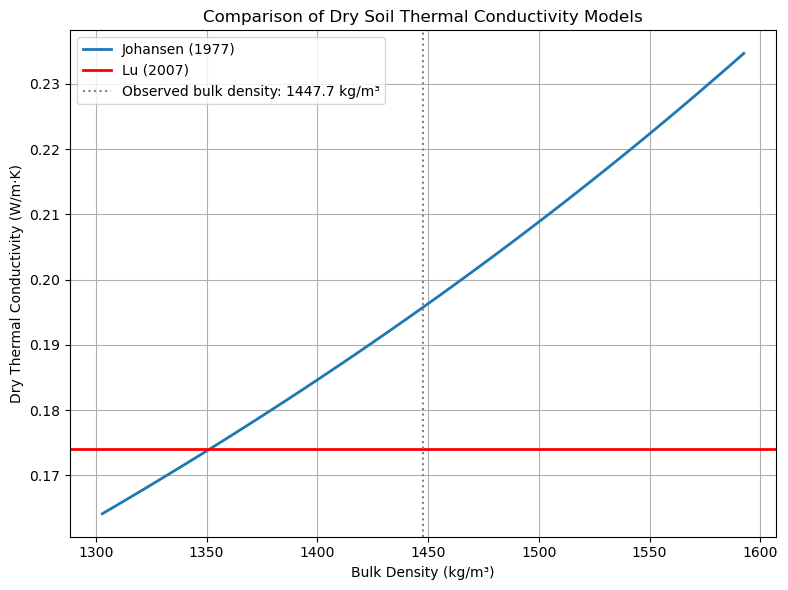

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Given soil properties
pct_clay = 56.4
pct_sand = 20.0
pct_silt = 100.0 - pct_clay - pct_sand  # Assume the rest is silt
bd_col = 1447.74  # Bulk density in kg/m3

# Define the bulk density in g/cm3 for Campbell
bd_g_cm3 = bd_col * 0.001  # Convert kg/m3 to g/cm3

# Define porosity
# Assume particle density (ρs) ~ 2.65 g/cm³
rho_s = 2.65  # g/cm³
porosity = 1.0 - bd_g_cm3 / rho_s

# Johansen dry thermal conductivity
# From your earlier formula:
def johansen_dry(bd):
    return (0.135 * bd + 64.7) / (2700 - 0.947 * bd)

# Lu et al. (2007) An Improved Model for Predicting Soil Thermal 
#                  Conductivity from Water Content at Room Temperature
def lu_dry(watsat):
    return -0.56*watsat+0.51

# Vary bulk density +/- 10% around given bd to see sensitivity
bd_range = np.linspace(0.9 * bd_col, 1.1 * bd_col, 100)

johansen_vals = johansen_dry(bd_range)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(bd_range, johansen_vals, label="Johansen (1977)", linewidth=2)
plt.axhline(lu_dry(0.6), label="Lu (2007)", linewidth=2, color = 'r')
plt.axvline(bd_col, color='grey', linestyle=':', label=f"Observed bulk density: {bd_col:.1f} kg/m³")
plt.xlabel("Bulk Density (kg/m³)")
plt.ylabel("Dry Thermal Conductivity (W/m·K)")
plt.title("Comparison of Dry Soil Thermal Conductivity Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

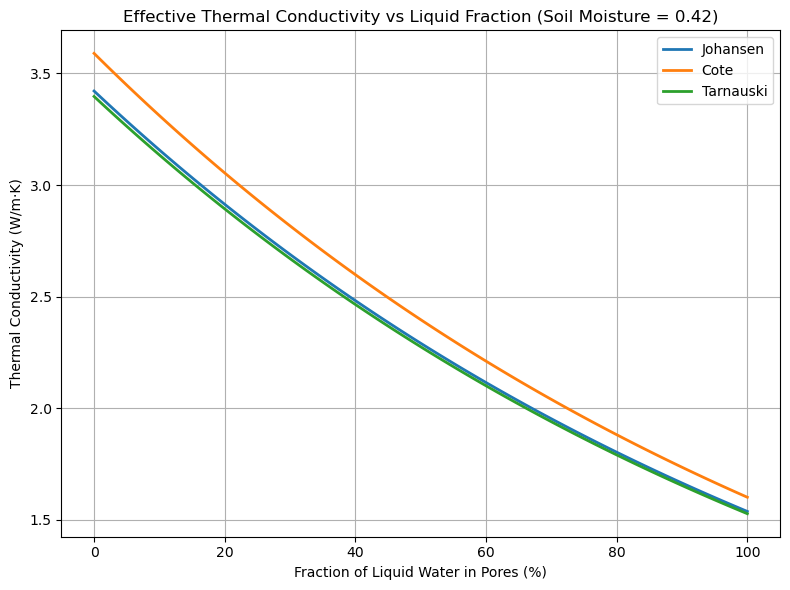

In [36]:
# Balland & Arp (2005)
def ke_balland_full(Sr, theta_sa, theta_gr, theta_om, a=1.0, b=6.0):
    """
    Full Balland and Arp (2005) Kersten number function.

    Parameters:
        Sr (float or np.array): degree of saturation (0–1)
        theta_sa (float): volumetric fraction of sand
        theta_gr (float): volumetric fraction of gravel
        theta_om (float): volumetric fraction of organic matter
        a (float): empirical coefficient (~1.0)
        b (float): empirical coefficient (~6.0)

    Returns:
        Ke (float or np.array): Kersten number
    """
    exponent = 0.5 * (1 + theta_om - a * theta_sa - a * theta_gr)
    first_term = Sr**exponent
    second_term = (1 / (1 + np.exp(-b * Sr)))**3 - (0.5 * (1 - Sr))**3
    Ke = first_term * (second_term**(1 - theta_om))
    Ke = np.maximum(Ke, 0.0)  # prevent negative values
    return Ke

def ke_cote(satw):
    Sr   = min(1, satw)
    kappa= 3.55            # 2.2 for peat, 4.7 if Vg > 0.3
    dke  = (kappa*Sr)/(1 + (kappa-1)*Sr)
    return dke

def cote_dry(watsat):
    return 0.30 * 10**(-0.87*watsat)

# Given constants
tkmg = 2.5  # Thermal conductivity of mineral matrix (W/m·K), typical for silicates
tkwat = 0.57  # Thermal conductivity of water (W/m·K)
tkice = 2.2  # Thermal conductivity of ice (W/m·K)
watsat = 0.6  # Porosity or saturated soil moisture content
satw = 0.42/watsat # % saturation

# Fractions of liquid water (from 0 to 1)
fl_range = np.linspace(0, 1, 100)  # 0% water (100% ice) to 100% water (0% ice)

# Kersten function with a = 1, b = 1 @ for fine soil
dke = max(0, np.log10(satw)+1)
dke_cote = ke_cote(satw)
dke_alt = max(0, ke_balland_full(satw, pct_sand/100, 0.14, 0.57))

# Calculate saturated thermal conductivity
dksat_values = tkmg * (tkwat)**(fl_range * watsat) * (tkice)**((1.0 - fl_range) * watsat)

# 
thk_values = dke * dksat_values + (1.0 - dke) * johansen_dry(bd_col)
thk_cote = dke_cote * dksat_values + (1.0 - dke_cote) * cote_dry(watsat)
thk_alt = dke_alt * dksat_values + (1.0 - dke_alt) * johansen_dry(bd_col)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fl_range * 100, thk_values, linewidth=2, label = 'Johansen')
plt.plot(fl_range * 100, thk_cote, linewidth=2, label = 'Cote')
plt.plot(fl_range * 100, thk_alt, linewidth=2, label = 'Tarnauski')
plt.legend()
plt.xlabel("Fraction of Liquid Water in Pores (%)")
plt.ylabel("Thermal Conductivity (W/m·K)")
plt.title("Effective Thermal Conductivity vs Liquid Fraction (Soil Moisture = 0.42)")
plt.grid(True)
plt.tight_layout()
plt.show()